In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import andes

In [2]:
import os
path=os.getcwd()
print(path)

C:\Users\basne\OneDrive - University of South Carolina\Desktop\inertia


In [25]:
# train_tsresnet_blocks_301.py
import os
import sys
import math
import traceback
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from time import time
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import Dataset, DataLoader


SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[Seed] set to {seed}")

set_seed(SEED)


def blocks_from_array(arr: np.ndarray, window_size: int):
    """
    arr: (T, D) - last column is label (we assume arr columns are [col_2, col_3, label])
    returns: X_blocks (M, window_size, C), y_labels (M,)
    Non-overlapping contiguous blocks. If T is not divisible by window_size,
    trailing remainder is dropped.
    Label used = value at the last sample in the block.
    """
    T, D = arr.shape
    C = D - 1
    if T < window_size:
        return np.empty((0, window_size, C)), np.empty((0,))
    M = T // window_size
    usable_len = M * window_size
    arr_cut = arr[:usable_len, :]  # drop tail
    resh = arr_cut.reshape(M, window_size, D)  # (M, L, D)
    X_blocks = resh[:, :, :C].astype(np.float32)  # (M, L, C)
    labels_ts = resh[:, :, -1]  # (M, L)
    y_labels = labels_ts[:, -1].astype(np.float32)  # last element of block
    return X_blocks, y_labels

# Dataset wrapper

class WindowDataset(Dataset):
    def __init__(self, X_windows: np.ndarray, y: np.ndarray):
        # X_windows: (N, window_size, C)
        self.X = X_windows.astype(np.float32)
        self.y = y.astype(np.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        x = self.X[idx].transpose(1,0).copy()  # (C, L)
        y = np.array([self.y[idx]], dtype=np.float32)
        return torch.from_numpy(x), torch.from_numpy(y)


# Model (TS-ResNet)
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, downsample=None):
        super().__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, 1, padding, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.downsample = downsample
    def forward(self, x):
        identity = x
        out = self.conv1(x); out = self.bn1(out); out = self.relu(out)
        out = self.conv2(out); out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(identity)
        out += identity
        return self.relu(out)

class TSResNet(nn.Module):
    def __init__(self, in_channels=2, layers=[2,2,2], channels=[32,64,128], kernel_size=3):
        super().__init__()
        assert len(layers) == len(channels)
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, channels[0], kernel_size=kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm1d(channels[0]),
            nn.ReLU(inplace=True)
        )
        self.stages = nn.ModuleList()
        in_ch = channels[0]
        for i, num_blocks in enumerate(layers):
            out_ch = channels[i]
            blocks = []
            for b in range(num_blocks):
                if i > 0 and b == 0:
                    downsample = nn.Sequential(
                        nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=2, bias=False),
                        nn.BatchNorm1d(out_ch)
                    )
                    blocks.append(ResidualBlock1D(in_ch, out_ch, kernel_size=kernel_size, stride=2, downsample=downsample))
                else:
                    blocks.append(ResidualBlock1D(in_ch, out_ch, kernel_size=kernel_size))
                in_ch = out_ch
            self.stages.append(nn.Sequential(*blocks))
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels[-1], 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        out = self.stem(x)
        for stage in self.stages:
            out = stage(out)
        out = self.global_pool(out)
        return self.fc(out)

# Training / evaluation helpers
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    it = tqdm(loader, desc="  batches", leave=False)
    for xb, yb in it:
        xb = xb.to(device); yb = yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running_loss += loss.item() * xb.size(0)
        it.set_postfix(loss=loss.item())
    return running_loss / max(1, len(loader.dataset))

def evaluate(model, loader, device, y_mean=0.0, y_std=1.0):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb).cpu().numpy().reshape(-1)
            preds.append(out); trues.append(yb.numpy().reshape(-1))
    if len(preds) == 0:
        return float('nan'), float('nan'), float('nan'), np.array([]), np.array([])
    preds = np.concatenate(preds); trues = np.concatenate(trues)
    mae_s = mean_absolute_error(trues, preds)
    rmse_s = math.sqrt(mean_squared_error(trues, preds))
    r2_s = r2_score(trues, preds)
    preds_un = preds * y_std + y_mean
    trues_un = trues * y_std + y_mean
    mae = mean_absolute_error(trues_un, preds_un)
    rmse = math.sqrt(mean_squared_error(trues_un, preds_un))
    r2 = r2_score(trues_un, preds_un)
    return (mae_s, rmse_s, r2_s), (mae, rmse, r2), preds_un, trues_un


# Main
def main():
    try:
        print("=== TRAIN (BLOCKS, 201 samples) START ===")
        print("Python:", sys.version.splitlines()[0])
        print("PyTorch:", torch.__version__)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print("Device:", device)

        csv_path = "final_data_filtered_r1.csv"  # set your CSV filename here
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"{csv_path} not found in cwd={os.getcwd()}")

        # ---------------- settings ----------------
        window_size = 201      # block length (samples per inertia label)
        batch_size = 128
        lr = 1e-4
        weight_decay = 1e-5
        num_epochs = 150
        test_fraction = 0.2
        use_fraction_of_blocks = 1.0  # fraction of blocks to use (1.0 = all)

        print(f"Loading CSV '{csv_path}' ...")
        df = pd.read_csv(csv_path)
        print("CSV columns:", df.columns.tolist())
        print("CSV rows:", len(df))
        print("CSV head:\n", df.head().to_string(index=False))

        # We only need col_2, col_3 as inputs and col_5 as label; ignore others
        required = ["coi_freq", "tie_line_changeP", "area2_inertia"]
        for c in required:
            if c not in df.columns:
                raise ValueError(f"Column '{c}' not found in CSV. Found columns: {df.columns.tolist()}")

        features = df[["coi_freq","tie_line_changeP"]].values.astype(np.float32)  # shape (T, 2)
        labels = df["area2_inertia"].values.astype(np.float32)               # shape (T,)

        # Build array concatenating features and label as last column
        arr = np.concatenate([features, labels.reshape(-1,1)], axis=1)
        print("Constructed array shape (T, D):", arr.shape)

        # Create non-overlapping blocks
        print(f"Creating non-overlapping blocks (window_size={window_size}) ...")
        X_blocks, y_labels = blocks_from_array(arr, window_size=window_size)
        print("Total blocks created:", X_blocks.shape[0])
        if X_blocks.shape[0] == 0:
            raise RuntimeError("No blocks created. Decrease window_size or provide more data.")

        # Optionally subsample fraction of blocks (deterministic RNG)
        N_blocks = X_blocks.shape[0]
        n_select = int(max(1, round(N_blocks * use_fraction_of_blocks)))
        print(f"Selecting subset: using {use_fraction_of_blocks*100:.0f}% -> {n_select}/{N_blocks} blocks")
        rng = np.random.default_rng(SEED)
        sel_idx = rng.choice(N_blocks, size=n_select, replace=False)
        X_blocks = X_blocks[sel_idx]
        y_labels = y_labels[sel_idx]

        #  Nested split (minimal change) 
        val_fraction_within_train = 0.20  # 20% of the remaining 80% -> 16% total for validation

        N_blocks = X_blocks.shape[0]
        if N_blocks == 0:
            raise RuntimeError("No blocks to split.")

        # Deterministic shuffle
        idxs = np.arange(N_blocks)
        rng = np.random.default_rng(SEED)   # fixed seed for reproducibility
        rng.shuffle(idxs)

        # compute sizes
        n_test = int(round(test_fraction * N_blocks))
        n_test = min(n_test, N_blocks - 1)  # ensure at least one sample remains for train_full
        test_idxs = idxs[:n_test]
        train_full_idxs = idxs[n_test:]

        # split train_full into train / val
        n_train_full = len(train_full_idxs)
        n_val = int(round(val_fraction_within_train * n_train_full))
        if n_train_full - n_val < 1 and n_train_full > 1:
            n_val = max(1, n_train_full - 1)
        split_point = n_train_full - n_val

        train_idxs = train_full_idxs[:split_point]
        val_idxs   = train_full_idxs[split_point:]

        print(f"Total blocks: {N_blocks} -> Test: {len(test_idxs)}, Train: {len(train_idxs)}, Val: {len(val_idxs)}")

        # Create splits
        X_test = X_blocks[test_idxs];   y_test = y_labels[test_idxs]
        X_train = X_blocks[train_idxs]; y_train = y_labels[train_idxs]
        X_val = X_blocks[val_idxs];     y_val = y_labels[val_idxs]

        # ---------- Fit scaler on TRAIN ONLY ----------
        N_train, _, C = X_train.shape
        flat_train = X_train.reshape(-1, C)
        print("Fitting StandardScaler on flattened TRAIN features shape:", flat_train.shape)
        scaler = StandardScaler().fit(flat_train)
        X_train_scaled = scaler.transform(flat_train).reshape(N_train, window_size, C)

        # scale validation and test using same scaler
        N_val = X_val.shape[0]
        X_val_scaled = scaler.transform(X_val.reshape(-1, C)).reshape(N_val, window_size, C)
        N_test = X_test.shape[0]
        X_test_scaled = scaler.transform(X_test.reshape(-1, C)).reshape(N_test, window_size, C)

        # ---------- Scale target (y) ----------
        y_mean = float(y_train.mean())
        y_std = float(y_train.std()) if y_train.std() > 0 else 1.0
        print(f"Target scaling: mean={y_mean:.6f}, std={y_std:.6f}")
        y_train_s = (y_train - y_mean) / y_std
        y_val_s = (y_val - y_mean) / y_std
        y_test_s = (y_test - y_mean) / y_std

        # Datasets & loaders (train/val as before; test kept for later prediction)
        train_ds = WindowDataset(X_train_scaled, y_train_s)
        val_ds = WindowDataset(X_val_scaled, y_val_s)
        test_ds = WindowDataset(X_test_scaled, y_test_s)   # keep this if you want to evaluate/predict now

        # deterministic dataloader generator
        g = torch.Generator()
        g.manual_seed(SEED)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, generator=g)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

        # Quick sanity
        sx, sy = train_ds[0]
        print("Example sample (C,L):", sx.shape, "target(scaled):", sy)

        # Model, optimizer, scheduler
        in_channels = C  # should be 2 (col_2 & col_3)
        model = TSResNet(in_channels=in_channels, layers=[2,2,2], channels=[32,64,128], kernel_size=3)
        model.to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

        criterion = nn.MSELoss()

        # containers for history
        train_mse_scaled_history = []
        train_mse_unscaled_history = []
        val_mse_scaled_history = []
        val_mse_unscaled_history = []

        best_val_rmse = float("inf")
        save_path = "tsresnet_best_blocks_301.pth"

        print("Start training for {} epochs ...".format(num_epochs))
        for epoch in range(1, num_epochs + 1):
            t0 = time()
            # TRAIN (train_one_epoch returns average scaled MSE over train set)
            train_loss_scaled = train_one_epoch(model, train_loader, optimizer, criterion, device)
            # convert to unscaled MSE (mathematically correct)
            train_loss_unscaled = train_loss_scaled * (y_std ** 2)

            # VALIDATE
            (mae_s, rmse_s, r2_s), (mae, rmse, r2), preds_val_un, trues_val_un = evaluate(model, val_loader, device, y_mean=y_mean, y_std=y_std)

            # derive val MSE scaled & unscaled
            val_mse_scaled = rmse_s ** 2
            if len(preds_val_un) > 0:
                val_mse_unscaled = mean_squared_error(trues_val_un, preds_val_un)
            else:
                val_mse_unscaled = float('nan')

            # store histories
            train_mse_scaled_history.append(float(train_loss_scaled))
            train_mse_unscaled_history.append(float(train_loss_unscaled))
            val_mse_scaled_history.append(float(val_mse_scaled))
            val_mse_unscaled_history.append(float(val_mse_unscaled))

            dt = time() - t0
            print(f"Epoch {epoch:02d}/{num_epochs} | Train MSE (scaled) {train_loss_scaled:.6f} | "
                  f"Train MSE (unscaled) {train_loss_unscaled:.6f} | "
                  f"Val MAE(scaled) {mae_s:.6f} Val RMSE(scaled) {rmse_s:.6f} | "
                  f"Val MSE (unscaled) {val_mse_unscaled:.6f} Val RMSE {rmse:.6f} | {dt:.1f}s")

            # scheduler step on unscaled RMSE
            try:
                scheduler.step(rmse)
            except Exception:
                pass

            # save best (unscaled rmse)
            if not math.isnan(rmse) and rmse < best_val_rmse:
                best_val_rmse = rmse
                torch.save({
                    "model_state": model.state_dict(),
                    "scaler": scaler,
                    "y_mean": y_mean,
                    "y_std": y_std,
                    "window_size": window_size
                }, save_path)
                print(f"  -> saved best model to {save_path} (Val RMSE={rmse:.6f}, R2={r2:.6f})")

        print("Training finished. Best val RMSE (unscaled):", best_val_rmse)

        # ------------------------------------------------------------
        # Save training/validation loss history to CSV
        # ------------------------------------------------------------
        try:
            df_losses = pd.DataFrame({
                "epoch": list(range(1, len(train_mse_scaled_history) + 1)),
                "train_mse_scaled": train_mse_scaled_history,
                "train_mse_unscaled": train_mse_unscaled_history,
                "val_mse_scaled": val_mse_scaled_history,
                "val_mse_unscaled": val_mse_unscaled_history
            })
            df_losses.to_csv("training_loss_history.csv", index=False)
            print("Saved: training_loss_history.csv")
        except Exception as e:
            print("Could not save training losses:", e)

        # save final predictions for validation set (last epoch evaluation)
        if len(val_ds) > 0:
            try:
                print("Saving validation predictions to val_predictions_blocks_201.csv ...")
                df_out = pd.DataFrame({"true": trues_val_un, "pred": preds_val_un})
                df_out["err"] = df_out["pred"] - df_out["true"]
                df_out.to_csv("val_predictions_blocks_201.csv", index=False)
                print("Saved", "val_predictions_blocks_201.csv", "rows =", df_out.shape[0])
            except Exception as e:
                print("Could not save val predictions:", e)

        # Evaluate on TEST set and save metrics + predictions
        if len(test_ds) > 0:
            (t_mae_s, t_rmse_s, t_r2_s), (t_mae, t_rmse, t_r2), preds_test_un, trues_test_un = evaluate(model, test_loader, device, y_mean=y_mean, y_std=y_std)
            test_mse_unscaled = mean_squared_error(trues_test_un, preds_test_un) if len(preds_test_un)>0 else float('nan')

            print("\nFinal Test (unscaled):")
            print(f" Test MSE={test_mse_unscaled:.6f} Test MAE={t_mae:.6f} Test RMSE={t_rmse:.6f} Test R2={t_r2:.6f}")

            # save test predictions
            try:
                df_test = pd.DataFrame({"true": trues_test_un, "pred": preds_test_un})
                df_test["err"] = df_test["pred"] - df_test["true"]
                df_test.to_csv("test_predictions_blocks_201.csv", index=False)
                print("Saved:", "test_predictions_blocks_201.csv")
            except Exception as e:
                print("Could not save test predictions:", e)

            # save test metrics
            try:
                metrics = {
                    "test_mse": float(test_mse_unscaled),
                    "test_mae": float(t_mae),
                    "test_rmse": float(t_rmse),
                    "test_r2": float(t_r2)
                }
                pd.Series(metrics).to_frame("value").to_csv("test_metrics_summary.csv")
                print("Saved: test_metrics_summary.csv")
            except Exception as e:
                print("Could not save test metrics:", e)
        else:
            print("No test data available – skipped final test evaluation/save.")

        print("=== DONE ===")
    except Exception as e:
        print("ERROR during script execution:")
        traceback.print_exc()
        sys.exit(1)

if __name__ == "__main__":
    main()


[Seed] set to 42
=== TRAIN (BLOCKS, 201 samples) START ===
Python: 3.11.13 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:03:15) [MSC v.1929 64 bit (AMD64)]
PyTorch: 2.9.0+cpu
Device: cpu
Loading CSV 'final_data_filtered_r1.csv' ...
CSV columns: ['time_s', 'coi_freq', 'coi_rocof', 'tie_line_changeP', 'area2_inertia']
CSV rows: 402000
CSV head:
  time_s  coi_freq     coi_rocof  tie_line_changeP  area2_inertia
  1.005 60.000000 -5.120000e-07          0.000055      12.537454
  1.010 59.999999 -1.940000e-06          0.000261      12.537454
  1.015 59.999998 -5.460000e-06          0.000474      12.537454
  1.020 59.999995 -1.220000e-05          0.000687      12.537454
  1.025 59.999991 -2.260000e-05          0.000897      12.537454
Constructed array shape (T, D): (402000, 3)
Creating non-overlapping blocks (window_size=201) ...
Total blocks created: 2000
Selecting subset: using 100% -> 2000/2000 blocks
Total blocks: 2000 -> Test: 400, Train: 1280, Val: 320
Fitting StandardScaler on f

Epoch 01/150 | Train MSE (scaled) 1.054431 | Train MSE (unscaled) 5.501286 | Val MAE(scaled) 0.778965 Val RMSE(scaled) 0.965112 | Val MSE (unscaled) 4.859608 Val RMSE 2.204452 | 4.3s
  -> saved best model to tsresnet_best_blocks_301.pth (Val RMSE=2.204452, R2=-0.007292)


Epoch 02/150 | Train MSE (scaled) 0.820427 | Train MSE (unscaled) 4.280418 | Val MAE(scaled) 0.777132 Val RMSE(scaled) 0.962855 | Val MSE (unscaled) 4.836905 Val RMSE 2.199296 | 4.7s
  -> saved best model to tsresnet_best_blocks_301.pth (Val RMSE=2.199296, R2=-0.002586)


Epoch 03/150 | Train MSE (scaled) 0.711628 | Train MSE (unscaled) 3.712782 | Val MAE(scaled) 0.790029 Val RMSE(scaled) 0.975428 | Val MSE (unscaled) 4.964050 Val RMSE 2.228015 | 5.2s


Epoch 04/150 | Train MSE (scaled) 0.635458 | Train MSE (unscaled) 3.315377 | Val MAE(scaled) 0.814520 Val RMSE(scaled) 1.001315 | Val MSE (unscaled) 5.231036 Val RMSE 2.287146 | 4.2s


...

Epoch 146/150 | Train MSE (scaled) 0.011355 | Train MSE (unscaled) 0.059245 | Val MAE(scaled) 0.083728 Val RMSE(scaled) 0.109026 | Val MSE (unscaled) 0.062017 Val RMSE 0.249032 | 4.0s


Epoch 147/150 | Train MSE (scaled) 0.011987 | Train MSE (unscaled) 0.062538 | Val MAE(scaled) 0.083787 Val RMSE(scaled) 0.109415 | Val MSE (unscaled) 0.062460 Val RMSE 0.249919 | 4.5s


Epoch 148/150 | Train MSE (scaled) 0.012112 | Train MSE (unscaled) 0.063192 | Val MAE(scaled) 0.083913 Val RMSE(scaled) 0.109593 | Val MSE (unscaled) 0.062663 Val RMSE 0.250325 | 4.3s


Epoch 149/150 | Train MSE (scaled) 0.013242 | Train MSE (unscaled) 0.069090 | Val MAE(scaled) 0.083754 Val RMSE(scaled) 0.109206 | Val MSE (unscaled) 0.062221 Val RMSE 0.249442 | 4.7s


Epoch 150/150 | Train MSE (scaled) 0.014828 | Train MSE (unscaled) 0.077361 | Val MAE(scaled) 0.083606 Val RMSE(scaled) 0.108876 | Val MSE (unscaled) 0.061846 Val RMSE 0.248689 | 4.4s
Training finished. Best val RMSE (unscaled): 0.24782243471808413
Saved: training_loss_history.csv
Saving validation predictions to val_predictions_blocks_201.csv ...
Saved val_predictions_blocks_201.csv rows = 320

Final Test (unscaled):
 Test MSE=0.058464 Test MAE=0.187868 Test RMSE=0.241794 Test R2=0.988858
Saved: test_predictions_blocks_201.csv
Saved: test_metrics_summary.csv
=== DONE ===


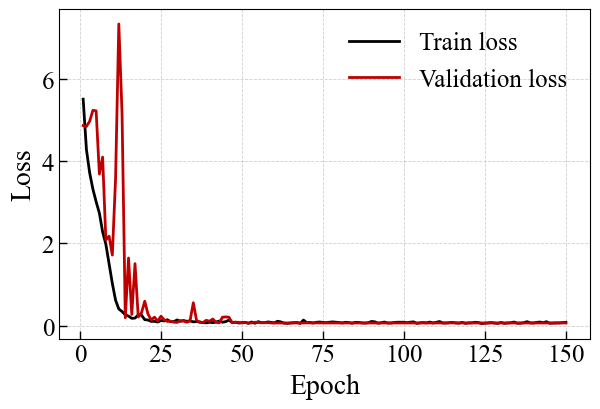

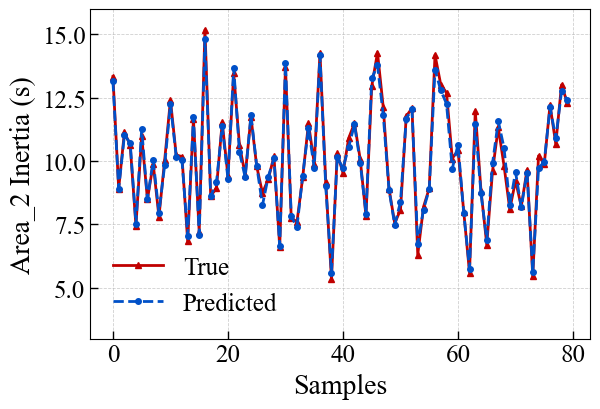

In [78]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


FIG_W, FIG_H = 6.4, 4.5   # consistent figure size
plt.rcParams.update({
    "font.family": "Times New Roman",       # elegant serif font like the example
    "font.size": 20,
    "axes.titlesize": 18,
    "axes.labelsize": 20,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "lines.linewidth": 2.0,
})

# Colors + markers matching your sample
COLORS = {
    "black": "#000000",
    "red":   "#C00000",
    "blue":  "#0050C8"
}
MARKERS = {
    "triangle": "^",
    "square":   "s",
    "circle":   "o"
}

def style_axis(ax):
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
    ax.tick_params(axis="both", direction="in", length=6, width=1)

# LOAD LOSS HISTORY 
loss_df = pd.read_csv("training_loss_history.csv")

fig = plt.figure(figsize=(FIG_W, FIG_H))
ax = fig.add_subplot(1,1,1)

ax.plot(loss_df["epoch"], loss_df["train_mse_unscaled"],
        color=COLORS["black"], label="Train loss")

ax.plot(loss_df["epoch"], loss_df["val_mse_unscaled"],
        color=COLORS["red"], label="Validation loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
# ax.set_title("Training / Validation MSE (unscaled)")

style_axis(ax)
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig("loss_area2.svg", dpi=300, format="svg")
plt.show()


val_pred_csv = "test_predictions_blocks_201.csv"
if os.path.exists(val_pred_csv):
    df_val = pd.read_csv(val_pred_csv)
    y = df_val["true"].values
    yhat = df_val["pred"].values
    n = min(80, len(y))
    idx = np.arange(n)

    fig = plt.figure(figsize=(FIG_W, FIG_H))
    ax = fig.add_subplot(1,1,1)

    ax.plot(idx, y[:n],
            color=COLORS["red"], marker=MARKERS["triangle"],
            markevery=1, markersize=4, label="True")

    ax.plot(idx, yhat[:n],
            color=COLORS["blue"], marker=MARKERS["circle"],
            linestyle="--",
            markevery=1, markersize=4, label="Predicted")

    ax.set_xlabel("Samples")
    ax.set_ylabel("Area_2 Inertia (s)")
#     ax.set_title("Test Samples: True vs Predicted")
    ax.set_ylim(3,16)
    style_axis(ax)
    ax.legend(frameon=False, loc="lower left")
    plt.tight_layout()
    fig.savefig("80_samples_area2.svg", dpi=300, format="svg")
    plt.show()

# # -----------------------------------------
# #  FIGURE 4 — Scatter
# # -----------------------------------------
# if os.path.exists(val_pred_csv):
#     df_val = pd.read_csv(val_pred_csv)
#     y = df_val["true"]
#     yhat = df_val["pred"]

#     fig = plt.figure(figsize=(5.2, 5.2))
#     ax = fig.add_subplot(1,1,1)

#     ax.scatter(y, yhat, s=25, color=COLORS["blue"], alpha=0.7)
#     mn, mx = min(y.min(), yhat.min()), max(y.max(), yhat.max())
#     ax.plot([mn, mx], [mn, mx], "--", color=COLORS["black"], linewidth=1.5)

#     ax.set_xlabel("True")
#     ax.set_ylabel("Predicted")
#     ax.set_title("Validation: Error Scatter")

#     style_axis(ax)
#     plt.tight_layout()
#     fig.savefig("val_scatter_journal.svg", dpi=300, format="svg")
#     plt.show()


In [28]:
# transfer_finetune_area1_FINAL.py

import os, sys, math, traceback
import numpy as np
import pandas as pd
import torch
import torch.nn as nn


def set_seed(seed=42):
    import random, os, numpy as _np, torch as _torch

    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    _np.random.seed(seed)
    _torch.manual_seed(seed)
    _torch.cuda.manual_seed_all(seed)

 
    try:
        _torch.use_deterministic_algorithms(True)
    except Exception:
        
        pass

    _torch.backends.cudnn.deterministic = True
    _torch.backends.cudnn.benchmark = False

    print(f"[Seed Set] Using deterministic seed = {seed}")


set_seed(1)

from time import time
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import Dataset, DataLoader

# MODEL DEFINITIONS

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, downsample=None):
        super().__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, 1, padding, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.downsample = downsample
    def forward(self, x):
        identity = x
        out = self.conv1(x); out = self.bn1(out); out = self.relu(out)
        out = self.conv2(out); out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(identity)
        out += identity
        return self.relu(out)

class TSResNet(nn.Module):
    def __init__(self, in_channels=2, layers=[2,2,2], channels=[32,64,128], kernel_size=3):
        super().__init__()
        assert len(layers) == len(channels)
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, channels[0], kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm1d(channels[0]),
            nn.ReLU(inplace=True)
        )
        self.stages = nn.ModuleList()
        in_ch = channels[0]
        for i, num_blocks in enumerate(layers):
            out_ch = channels[i]
            blocks = []
            for b in range(num_blocks):
                if i > 0 and b == 0:
                    downsample = nn.Sequential(
                        nn.Conv1d(in_ch, out_ch, 1, stride=2, bias=False),
                        nn.BatchNorm1d(out_ch)
                    )
                    blocks.append(ResidualBlock1D(in_ch, out_ch, kernel_size, stride=2, downsample=downsample))
                else:
                    blocks.append(ResidualBlock1D(in_ch, out_ch, kernel_size))
                in_ch = out_ch
            self.stages.append(nn.Sequential(*blocks))
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels[-1], 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        out = self.stem(x)
        for stage in self.stages:
            out = stage(out)
        out = self.global_pool(out)
        return self.fc(out)


# DATASET
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32) # shape (N, L, 2)
        self.y = y.astype(np.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        x = self.X[idx].transpose(1,0).copy() # becomes (2, L)
        y = np.array([self.y[idx]], np.float32)
        return torch.from_numpy(x), torch.from_numpy(y)

def evaluate(model, loader, device, y_mean, y_std):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb).cpu().numpy().reshape(-1)
            preds.append(out)
            trues.append(yb.numpy().reshape(-1))
    if len(preds) == 0:
        return float('nan'), float('nan'), float('nan'), [], []
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    # scaled metrics
    mae_s = mean_absolute_error(trues, preds)
    rmse_s = math.sqrt(mean_squared_error(trues, preds))
    r2_s = r2_score(trues, preds)
    # unscaled
    preds_un = preds * y_std + y_mean
    trues_un = trues * y_std + y_mean
    mae = mean_absolute_error(trues_un, preds_un)
    rmse = math.sqrt(mean_squared_error(trues_un, preds_un))
    r2 = r2_score(trues_un, preds_un)
    return (mae_s, rmse_s, r2_s), (mae, rmse, r2), preds_un, trues_un


# MAIN FUNCTION — TRANSFER LEARNING
def transfer_and_finetune_area1(csv_path="final_data_filtered_area1.csv",
                                checkpoint="tsresnet_best_blocks_301.pth",
                                window_size=201,
                                batch_size=64,
                                lr=1e-4,
                                weight_decay=1e-5,
                                fine_tune_epochs=100,
                                device=None,
                                freeze_base=False):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    print("Loading CSV:", csv_path)
    df = pd.read_csv(csv_path)
    # *** FIX: ONLY KEEP THESE 3 COLUMNS ***
    required = ["coi_freq", "tie_line_changeP", "area1_inertia"]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"Column '{c}' missing from CSV")
    # Keep exactly the expected columns
    arr = df[required].values.astype(np.float32)
    T = arr.shape[0]
    if T % window_size != 0:
        raise ValueError(f"80400 rows should be divisible by 201 — but got T={T}")
    n_samples = T // window_size
    print("Detected:", n_samples, "samples of length", window_size)
    # Build windows (N, L, C=2)
    arr3 = arr.reshape(n_samples, window_size, 3)
    X_blocks = arr3[:, :, :2]
    y_labels = arr3[:, -1, 2]
    # --- deterministic 70/15/15 split ---
    rng = np.random.default_rng(1)
    idxs = np.arange(n_samples)
    rng.shuffle(idxs)
    n_test = max(1, int(round(0.10 * n_samples)))
    n_val = max(1, int(round(0.10 * n_samples)))
    n_train = n_samples - n_val - n_test
    train_idx = idxs[:n_train]
    val_idx = idxs[n_train:n_train+n_val]
    test_idx = idxs[n_train+n_val:]
    X_train, y_train = X_blocks[train_idx], y_labels[train_idx]
    X_val, y_val = X_blocks[val_idx], y_labels[val_idx]
    X_test, y_test = X_blocks[test_idx], y_labels[test_idx]
    print(f"Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")
   
    # LOAD CHECKPOINT SAFELY
 
    from sklearn.preprocessing import StandardScaler
    torch.serialization.add_safe_globals([StandardScaler])
    ckpt = torch.load(checkpoint, map_location="cpu", weights_only=False)
    model_state = ckpt["model_state"]
    scaler = ckpt["scaler"]
    y_mean = ckpt["y_mean"]
    y_std = ckpt["y_std"]
   
    # SCALE FEATURES
 
    flat_train = X_train.reshape(-1, 2)
    X_train_s = scaler.transform(flat_train).reshape(X_train.shape)
    X_val_s = scaler.transform(X_val.reshape(-1,2)).reshape(X_val.shape)
    X_test_s = scaler.transform(X_test.reshape(-1,2)).reshape(X_test.shape)
    # scale labels
    y_train_s = (y_train - y_mean) / y_std
    y_val_s = (y_val - y_mean) / y_std
    y_test_s = (y_test - y_mean) / y_std
    # datasets
    train_ds = WindowDataset(X_train_s, y_train_s)
    val_ds = WindowDataset(X_val_s, y_val_s)
    test_ds = WindowDataset(X_test_s, y_test_s)
    # DataLoader deterministic options
    # Note: worker_init_fn and generator with torch.Generator ensure deterministic worker behavior
    gen = torch.Generator()
    gen.manual_seed(1)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=gen)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
  
    # BUILD MODEL AND LOAD WEIGHTS
 
    model = TSResNet(in_channels=2)
    model.load_state_dict(model_state, strict=False)
    model.to(device)
    if freeze_base:
        for name, param in model.named_parameters():
            param.requires_grad = name.startswith("fc")
        print("Frozen backbone — training FC only")
    else:
        print("Training all layers (fine-tuning full model)")
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                                 lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
    criterion = nn.MSELoss()

  
    # tracking lists for graphs (no plotting here)

    train_losses = []   # stores average train loss (scaled MSE) per epoch
    val_losses = []     # stores validation MSE (unscaled) per epoch
    best_val_mse = float("inf")


    # TRAIN / FINE-TUNE
    
    for epoch in range(1, fine_tune_epochs+1):
        model.train()
        total_loss_sum = 0.0
        total_samples = 0
          

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_n = xb.size(0)
            total_loss_sum += loss.item() * batch_n
            total_samples += batch_n

        # average train loss (scaled units)
        avg_train_loss_scaled = total_loss_sum / total_samples

        # convert scaled MSE to unscaled MSE
        avg_train_loss_unscaled = avg_train_loss_scaled * (y_std ** 2)

        train_losses.append(avg_train_loss_unscaled)

        # Evaluate on validation set; get unscaled preds & trues for val MSE
        (mae_s, rmse_s, r2_s), (mae, rmse, r2), preds_un_val, trues_un_val = evaluate(
            model, val_loader, device, y_mean, y_std
        )

        # validation MSE (unscaled)
        if len(preds_un_val) > 0:
            val_mse_unscaled = mean_squared_error(trues_un_val, preds_un_val)
            
        else:
            val_mse_unscaled = float('nan')
            
            
        val_losses.append(val_mse_unscaled)

        print(f"Epoch {epoch}: TrainLoss_unscaled_avg={avg_train_loss_unscaled:.6f} Val_MSE_unscaled={val_mse_unscaled:.6f} Val_RMSE_unscaled={rmse:.6f}")

        scheduler.step(val_mse_unscaled)

        # save best checkpoint (keeps your original saving of ckpt with this name)
        if val_mse_unscaled < best_val_mse:
            best_val_mse = val_mse_unscaled
            try:
                torch.save(ckpt, "tsresnet_area1_finetuned.pth")
                print("Saved improved model (tsresnet_area1_finetuned.pth)")
            except Exception as e:
                print("Could not save checkpoint:", e)

    # Save loss history to CSV
  
    try:
        df_losses = pd.DataFrame({
            "epoch": list(range(1, len(train_losses) + 1)),
            "train_loss_unscaled_avg": train_losses,
            "val_mse_unscaled": val_losses
        })
        df_losses.to_csv("training_loss_history_area1.csv", index=False)
        print("Saved: training_loss_history_area1.csv")
    except Exception as e:
        print("Could not save training losses:", e)

 
    # FINAL TEST
    
    (mae_s, rmse_s, r2_s), (mae, rmse, r2), preds_un, trues_un = evaluate(
        model, test_loader, device, y_mean, y_std
    )

    # compute unscaled test metrics
    if len(preds_un) > 0:
        test_mse = mean_squared_error(trues_un, preds_un)
        test_mae = mean_absolute_error(trues_un, preds_un)
        test_rmse = math.sqrt(mean_squared_error(trues_un, preds_un))
        test_r2 = r2_score(trues_un, preds_un)
    else:
        test_mse = test_mae = test_rmse = test_r2 = float('nan')

    print("\nFinal Test (unscaled):")
    print(f" MSE={test_mse:.6f} MAE={test_mae:.6f} RMSE={test_rmse:.6f} R2={test_r2:.6f}")

    out = pd.DataFrame({"true": trues_un, "pred": preds_un})
    out.to_csv("area1_transfer_test_predictions.csv", index=False)
    print("Saved:", "area1_transfer_test_predictions.csv")

    # save test metrics summary
    try:
        metrics = {
            "test_mse": float(test_mse),
            "test_mae": float(test_mae),
            "test_rmse": float(test_rmse),
            "test_r2": float(test_r2)
        }
        pd.Series(metrics).to_frame("value").to_csv("test_metrics_summary_area1.csv")
        print("Saved: test_metrics_summary.csv")
    except Exception as e:
        print("Could not save test metrics:", e)

    return model

# ------------------------------------------------------------
# RUN SCRIPT
# ------------------------------------------------------------
if __name__ == "__main__":
    transfer_and_finetune_area1()


[Seed Set] Using deterministic seed = 1
Device: cpu
Loading CSV: final_data_filtered_area1.csv
Detected: 500 samples of length 201
Train=400, Val=50, Test=50
Training all layers (fine-tuning full model)
Epoch 1: TrainLoss_unscaled_avg=3.408229 Val_MSE_unscaled=595.707947 Val_RMSE_unscaled=24.407129
Saved improved model (tsresnet_area1_finetuned.pth)
Epoch 2: TrainLoss_unscaled_avg=2.827377 Val_MSE_unscaled=11.086468 Val_RMSE_unscaled=3.329635
Saved improved model (tsresnet_area1_finetuned.pth)
Epoch 3: TrainLoss_unscaled_avg=2.432664 Val_MSE_unscaled=9.426430 Val_RMSE_unscaled=3.070249
Saved improved model (tsresnet_area1_finetuned.pth)
Epoch 4: TrainLoss_unscaled_avg=2.305128 Val_MSE_unscaled=3.549423 Val_RMSE_unscaled=1.883991
Saved improved model (tsresnet_area1_finetuned.pth)
Epoch 5: TrainLoss_unscaled_avg=2.097262 Val_MSE_unscaled=2.348049 Val_RMSE_unscaled=1.532334
Saved improved model (tsresnet_area1_finetuned.pth)
Epoch 6: TrainLoss_unscaled_avg=1.847644 Val_MSE_unscaled=2.014

Epoch 73: TrainLoss_unscaled_avg=0.108993 Val_MSE_unscaled=0.124724 Val_RMSE_unscaled=0.353162
Epoch 74: TrainLoss_unscaled_avg=0.114802 Val_MSE_unscaled=0.129751 Val_RMSE_unscaled=0.360210
Epoch 75: TrainLoss_unscaled_avg=0.165355 Val_MSE_unscaled=0.121861 Val_RMSE_unscaled=0.349086
Epoch 76: TrainLoss_unscaled_avg=0.114383 Val_MSE_unscaled=0.123813 Val_RMSE_unscaled=0.351871
Epoch 77: TrainLoss_unscaled_avg=0.119665 Val_MSE_unscaled=0.122554 Val_RMSE_unscaled=0.350077
Epoch 78: TrainLoss_unscaled_avg=0.128820 Val_MSE_unscaled=0.123445 Val_RMSE_unscaled=0.351347
Epoch 79: TrainLoss_unscaled_avg=0.111129 Val_MSE_unscaled=0.122450 Val_RMSE_unscaled=0.349928
Epoch 80: TrainLoss_unscaled_avg=0.132492 Val_MSE_unscaled=0.122157 Val_RMSE_unscaled=0.349510
Epoch 81: TrainLoss_unscaled_avg=0.135184 Val_MSE_unscaled=0.125003 Val_RMSE_unscaled=0.353557
Epoch 82: TrainLoss_unscaled_avg=0.120895 Val_MSE_unscaled=0.119331 Val_RMSE_unscaled=0.345443
Saved improved model (tsresnet_area1_finetuned.pth

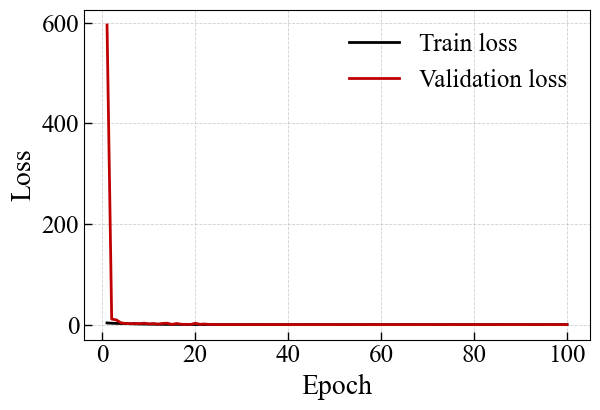

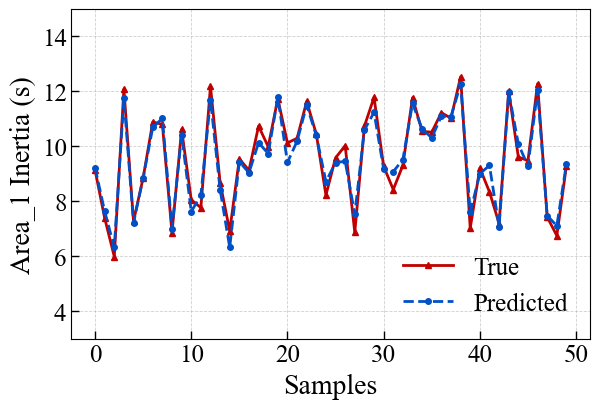

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


FIG_W, FIG_H = 6.4, 4.5   # consistent figure size
plt.rcParams.update({
    "font.family": "Times New Roman",       # elegant serif font like the example
    "font.size": 20,
    "axes.titlesize": 18,
    "axes.labelsize": 20,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "lines.linewidth": 2.0,
})

# Colors + markers matching your sample
COLORS = {
    "black": "#000000",
    "red":   "#C00000",
    "blue":  "#0050C8"
}
MARKERS = {
    "triangle": "^",
    "square":   "s",
    "circle":   "o"
}

def style_axis(ax):
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
    ax.tick_params(axis="both", direction="in", length=6, width=1)

# ----------- LOAD LOSS HISTORY ----------
loss_df = pd.read_csv("training_loss_history_area1.csv")


fig = plt.figure(figsize=(FIG_W, FIG_H))
ax = fig.add_subplot(1,1,1)

ax.plot(loss_df["epoch"], loss_df["train_loss_unscaled_avg"],
        color=COLORS["black"], label="Train loss")

ax.plot(loss_df["epoch"], loss_df["val_mse_unscaled"],
        color=COLORS["red"], label="Validation loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
# ax.set_title("Training / Validation MSE (unscaled)")

style_axis(ax)
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig("loss_area1.svg", dpi=300, format="svg")
plt.show()


val_pred_csv = "area1_transfer_test_predictions.csv"
if os.path.exists(val_pred_csv):
    df_val = pd.read_csv(val_pred_csv)
    y = df_val["true"].values
    yhat = df_val["pred"].values
    n = min(50, len(y))
    idx = np.arange(n)

    fig = plt.figure(figsize=(FIG_W, FIG_H))
    ax = fig.add_subplot(1,1,1)

    ax.plot(idx, y[:n],
            color=COLORS["red"], marker=MARKERS["triangle"],
            markevery=1, markersize=4, label="True")

    ax.plot(idx, yhat[:n],
            color=COLORS["blue"], marker=MARKERS["circle"],
            linestyle="--",
            markevery=1, markersize=4, label="Predicted")

    ax.set_xlabel("Samples")
    ax.set_ylabel("Area_1 Inertia (s)")
#     ax.set_title("Test Samples: True vs Predicted")
    ax.set_ylim(3,15)
    style_axis(ax)
    ax.legend(frameon=False, loc="lower right")
    plt.tight_layout()
    fig.savefig("50_samples_area1.svg", dpi=300, format="svg")
    plt.show()

# # -----------------------------------------
# #  FIGURE 4 — Scatter
# # -----------------------------------------
# if os.path.exists(val_pred_csv):
#     df_val = pd.read_csv(val_pred_csv)
#     y = df_val["true"]
#     yhat = df_val["pred"]

#     fig = plt.figure(figsize=(5.2, 5.2))
#     ax = fig.add_subplot(1,1,1)

#     ax.scatter(y, yhat, s=25, color=COLORS["blue"], alpha=0.7)
#     mn, mx = min(y.min(), yhat.min()), max(y.max(), yhat.max())
#     ax.plot([mn, mx], [mn, mx], "--", color=COLORS["black"], linewidth=1.5)

#     ax.set_xlabel("True")
#     ax.set_ylabel("Predicted")
#     ax.set_title("Validation: Error Scatter")

#     style_axis(ax)
#     plt.tight_layout()
#     fig.savefig("val_scatter_journal.svg", dpi=300, format="svg")
#     plt.show()

